In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer

In [87]:
df = pd.read_csv("data/final_house_data.csv")

In [88]:
df.head()

,listing_id,city_name,district_name,neighborhood_name,title,price,room_count,gross_sqm,net_sqm,building_age,floor_level,heating_type,is_furnished
0,12854-258,Istanbul,Adalar,Heybeliada,HEYBELİADA'DA DENİZ VE DOĞA MANZARALI DUBLEKS ...,16000000,3 + 1,200,196,35 Yaşında,En Üst Kat,Kombi,Eşyalı Değil
1,12854-260,Istanbul,Adalar,Heybeliada,HEYBELİADA 1 DÖNÜM BAHÇE İÇİNDE ORTA KAT DAİRE,13750000,2 + 1,80,75,8 Yaşında,Ara Kat,Kat Kaloriferi,Eşyalı Değil
2,4387-1728,Istanbul,Adalar,Maden,BÜYÜKADADA DOĞA İÇİNDE İYOT VE OKSİJEN DOLU Bİ...,21900000,4 + 1,160,150,30 Yaşında,En Üst Kat,Kombi,Eşyalı
3,4387-1446,Istanbul,Adalar,Maden,BÜYÜKADADA GÖKHANDAN HAVUZLU MANZARALI DUBLEKS...,12000000,3 + 1,140,130,33 Yaşında,3. Kat,Klima,Eşyalı Değil
4,4387-1717,Istanbul,Adalar,Nizam,"BÜYÜKADADA İSKELEYE, AND.KLÜBÜNE, DEVLET HAST...",20000000,3 + 1,130,120,30 Yaşında,2. Kat,Kombi,Eşyalı


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2143 entries, 0 to 2142
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   listing_id         2143 non-null   object
 1   city_name          2143 non-null   object
 2   district_name      2143 non-null   object
 3   neighborhood_name  2143 non-null   object
 4   title              2143 non-null   object
 5   price              2143 non-null   int64 
 6   room_count         2143 non-null   object
 7   gross_sqm          2143 non-null   int64 
 8   net_sqm            2143 non-null   int64 
 9   building_age       2143 non-null   object
 10  floor_level        2143 non-null   object
 11  heating_type       2143 non-null   object
 12  is_furnished       2072 non-null   object
dtypes: int64(3), object(10)
memory usage: 217.8+ KB


In [90]:
def parse_age(age_str):
    if 'Sıfır' in age_str:
        return 0
    try:
        return int(age_str.split(' ')[0])
    except:
        return 0
df['building_age_num'] = df['building_age'].apply(parse_age)

In [91]:
df.head()

,listing_id,city_name,district_name,neighborhood_name,title,price,room_count,gross_sqm,net_sqm,building_age,floor_level,heating_type,is_furnished,building_age_num
0,12854-258,Istanbul,Adalar,Heybeliada,HEYBELİADA'DA DENİZ VE DOĞA MANZARALI DUBLEKS ...,16000000,3 + 1,200,196,35 Yaşında,En Üst Kat,Kombi,Eşyalı Değil,35
1,12854-260,Istanbul,Adalar,Heybeliada,HEYBELİADA 1 DÖNÜM BAHÇE İÇİNDE ORTA KAT DAİRE,13750000,2 + 1,80,75,8 Yaşında,Ara Kat,Kat Kaloriferi,Eşyalı Değil,8
2,4387-1728,Istanbul,Adalar,Maden,BÜYÜKADADA DOĞA İÇİNDE İYOT VE OKSİJEN DOLU Bİ...,21900000,4 + 1,160,150,30 Yaşında,En Üst Kat,Kombi,Eşyalı,30
3,4387-1446,Istanbul,Adalar,Maden,BÜYÜKADADA GÖKHANDAN HAVUZLU MANZARALI DUBLEKS...,12000000,3 + 1,140,130,33 Yaşında,3. Kat,Klima,Eşyalı Değil,33
4,4387-1717,Istanbul,Adalar,Nizam,"BÜYÜKADADA İSKELEYE, AND.KLÜBÜNE, DEVLET HAST...",20000000,3 + 1,130,120,30 Yaşında,2. Kat,Kombi,Eşyalı,30


In [92]:
df["building_age_num"].value_counts()

building_age_num
0      495
6      309
11     186
5      139
31      94
26      83
1       73
16      72
3       67
2       66
4       61
21      53
8       51
30      41
10      39
7       33
9       30
40      27
15      24
25      20
12      18
35      16
45      15
13      13
14      10
27       9
29       9
28       9
18       8
20       8
39       6
23       6
24       5
50       5
22       4
38       4
19       4
37       4
33       4
17       4
34       4
36       3
55       2
32       2
43       2
47       2
42       2
80       1
123      1
Name: count, dtype: int64

In [93]:
def parse_rooms(room_str):
    try:
        parts = room_str.split('+')
        return sum([int(p.strip()) for p in parts])
    except:
        return 1
df['total_rooms'] = df['room_count'].apply(parse_rooms)

In [94]:
df.head()

,listing_id,city_name,district_name,neighborhood_name,title,price,room_count,gross_sqm,net_sqm,building_age,floor_level,heating_type,is_furnished,building_age_num,total_rooms
0,12854-258,Istanbul,Adalar,Heybeliada,HEYBELİADA'DA DENİZ VE DOĞA MANZARALI DUBLEKS ...,16000000,3 + 1,200,196,35 Yaşında,En Üst Kat,Kombi,Eşyalı Değil,35,4
1,12854-260,Istanbul,Adalar,Heybeliada,HEYBELİADA 1 DÖNÜM BAHÇE İÇİNDE ORTA KAT DAİRE,13750000,2 + 1,80,75,8 Yaşında,Ara Kat,Kat Kaloriferi,Eşyalı Değil,8,3
2,4387-1728,Istanbul,Adalar,Maden,BÜYÜKADADA DOĞA İÇİNDE İYOT VE OKSİJEN DOLU Bİ...,21900000,4 + 1,160,150,30 Yaşında,En Üst Kat,Kombi,Eşyalı,30,5
3,4387-1446,Istanbul,Adalar,Maden,BÜYÜKADADA GÖKHANDAN HAVUZLU MANZARALI DUBLEKS...,12000000,3 + 1,140,130,33 Yaşında,3. Kat,Klima,Eşyalı Değil,33,4
4,4387-1717,Istanbul,Adalar,Nizam,"BÜYÜKADADA İSKELEYE, AND.KLÜBÜNE, DEVLET HAST...",20000000,3 + 1,130,120,30 Yaşında,2. Kat,Kombi,Eşyalı,30,4


In [95]:
df["floor_level"].value_counts()

floor_level
2. Kat             290
3. Kat             274
1. Kat             273
4. Kat             232
Bahçe Katı         205
Yüksek Giriş       137
5. Kat             133
6. Kat              93
Giriş Katı          65
Ara Kat             54
7. Kat              53
8. Kat              48
9. Kat              48
10. Kat             35
21 ve üzeri         23
12. Kat             20
11. Kat             20
14. Kat             14
En Üst Kat          13
13. Kat             13
Yarı Bodrum         13
Zemin               12
16. Kat             10
20. Kat              9
15. Kat              8
19. Kat              8
Bodrum               7
17. Kat              7
0. Kat               6
21. Kat              6
Çatı Katı            6
18. Kat              5
Bodrum ve Zemin      2
Kot 1                1
Name: count, dtype: int64

In [96]:
import re

def convert_floor_to_numeric(floor_str):
    if not isinstance(floor_str, str):
        return 0

    floor_str = floor_str.lower()

    if "bodrum" in floor_str:
        return -1
    elif "giriş" in floor_str or "zemin" in floor_str or "bahçe" in floor_str or "kot" in floor_str:
        return 1
    elif "ara kat" in floor_str:
        return 4
    elif "üst" in floor_str or "çatı" in floor_str:
        return 6
    elif "üzeri" in floor_str:
        return 21

    match = re.search(r"\d+", floor_str)
    if match:
        return int(match.group())
    return 1

df['floor_level_num'] = df['floor_level'].apply(convert_floor_to_numeric)

In [97]:
df["floor_level_num"].value_counts()

floor_level_num
 1     693
 2     290
 4     286
 3     274
 5     133
 6     112
 7      53
 9      48
 8      48
 10     35
 21     29
-1      22
 12     20
 11     20
 14     14
 13     13
 16     10
 20      9
 15      8
 19      8
 17      7
 0       6
 18      5
Name: count, dtype: int64

In [98]:
df["is_furnished"].fillna("Eşyalı Değil", inplace=True)

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_17332\3831073873.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["is_furnished"].fillna("Eşyalı Değil", inplace=True)


In [99]:
df["is_furnished"].value_counts()

is_furnished
Eşyalı Değil    2046
Eşyalı            97
Name: count, dtype: int64

In [100]:
df["heating_type"].value_counts()

heating_type
Kombi                 1475
Merkezi (Pay Öl...     396
Yerden Isıtma          132
Merkezi                 92
Doğalgaz Sobası         13
Klima                   12
VRV                      9
Kat Kaloriferi           6
Isıtma Yok               5
Soba                     2
Belirtilmemiş            1
Name: count, dtype: int64

In [101]:
df["heating_type"] = df["heating_type"].replace("Merkezi (Pay Öl...", "Merkezi")
df["heating_type"].value_counts()

heating_type
Kombi              1475
Merkezi             488
Yerden Isıtma       132
Doğalgaz Sobası      13
Klima                12
VRV                   9
Kat Kaloriferi        6
Isıtma Yok            5
Soba                  2
Belirtilmemiş         1
Name: count, dtype: int64

In [102]:
rare_classes = ['Doğalgaz Sobası', 'Klima', 'VRV', 'Kat Kaloriferi', 'Isıtma Yok', 'Soba', 'Belirtilmemiş']
df["heating_type"] = df["heating_type"].replace(rare_classes, "Diğer")
df["heating_type"].value_counts()

heating_type
Kombi            1475
Merkezi           488
Yerden Isıtma     132
Diğer              48
Name: count, dtype: int64

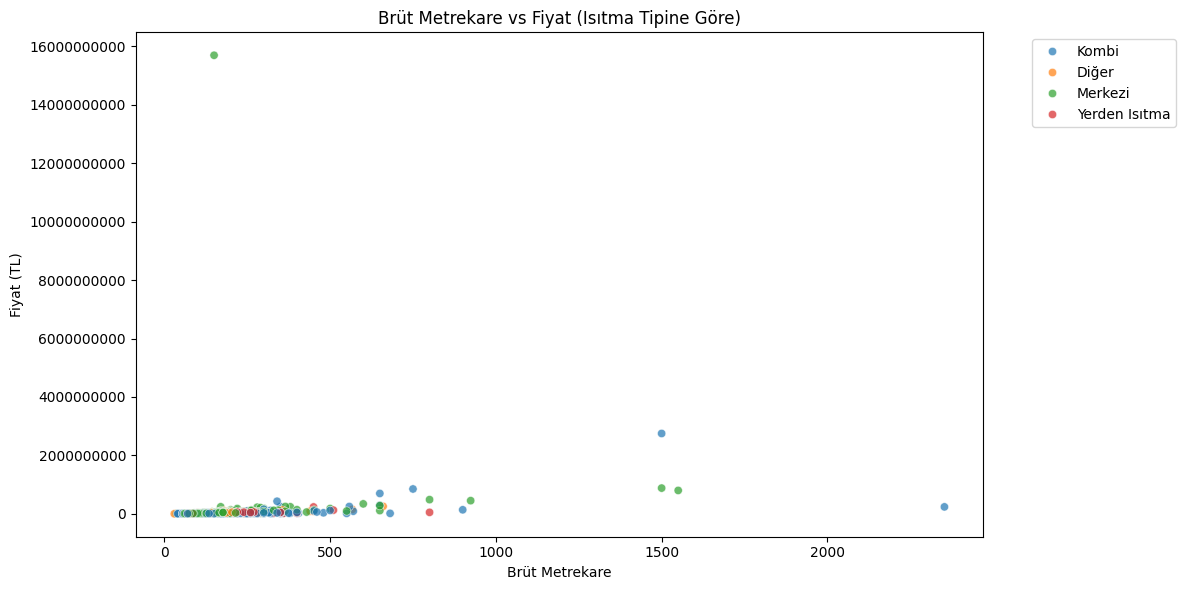

In [103]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='gross_sqm', y='price', hue='heating_type', data=df, alpha=0.7)
plt.title('Brüt Metrekare vs Fiyat (Isıtma Tipine Göre)')
plt.xlabel('Brüt Metrekare')
plt.ylabel('Fiyat (TL)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Lejantı dışarı alma
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [104]:
(df['price'] > 50000000).sum()

117

In [105]:
(df['gross_sqm'] > 500).sum()

22

In [106]:
df_filtred = df[(df['price'] < 50000000) & (df['gross_sqm'] < 500)].copy()

In [107]:
numeric_df = df_filtred.select_dtypes(include=['int64', 'float64'])
numeric_df.corr()

,price,gross_sqm,net_sqm,building_age_num,total_rooms,floor_level_num
price,1.000000,0.573594,0.501094,-0.093424,0.359081,0.212399
gross_sqm,0.573594,1.000000,0.967574,-0.014113,0.667080,0.125876
net_sqm,0.501094,0.967574,1.000000,0.035940,0.673942,0.066493
building_age_num,-0.093424,-0.014113,0.035940,1.000000,0.029263,-0.089518
total_rooms,0.359081,0.667080,0.673942,0.029263,1.000000,0.027478
floor_level_num,0.212399,0.125876,0.066493,-0.089518,0.027478,1.000000


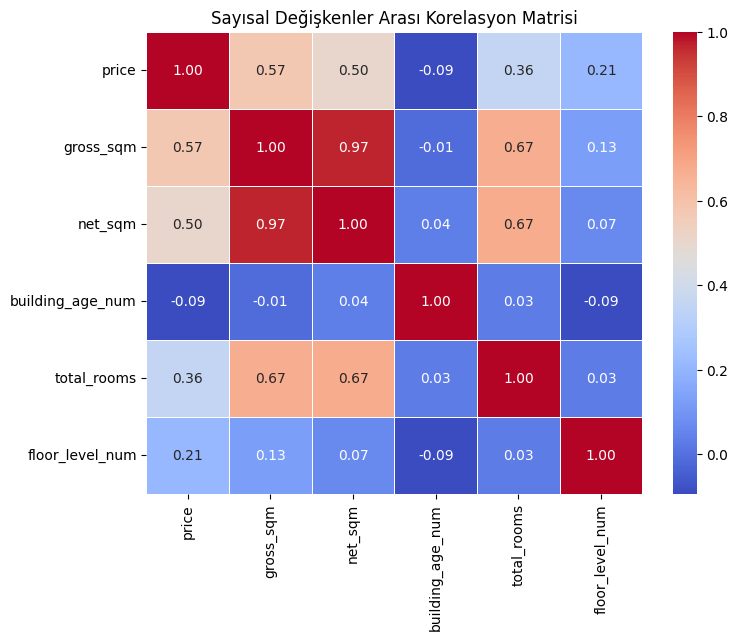

In [108]:
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Sayısal Değişkenler Arası Korelasyon Matrisi")
plt.show()

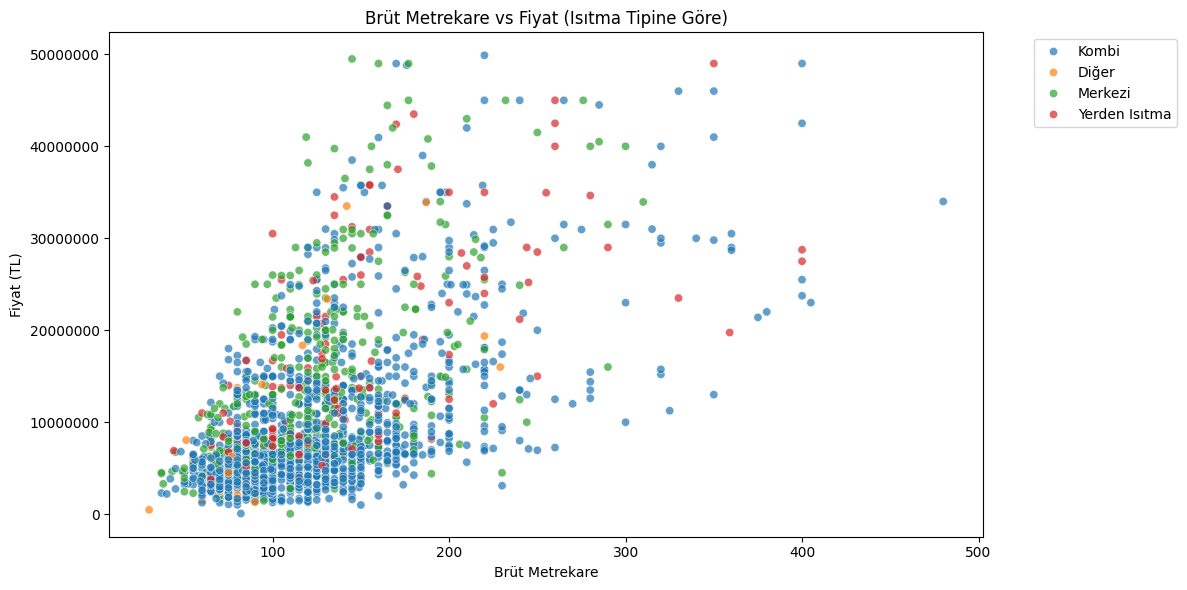

In [109]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='gross_sqm', y='price', hue='heating_type', data=df_filtred, alpha=0.7)
plt.title('Brüt Metrekare vs Fiyat (Isıtma Tipine Göre)')
plt.xlabel('Brüt Metrekare')
plt.ylabel('Fiyat (TL)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [110]:
df_filtred.head()

,listing_id,city_name,district_name,neighborhood_name,title,price,room_count,gross_sqm,net_sqm,building_age,floor_level,heating_type,is_furnished,building_age_num,total_rooms,floor_level_num
0,12854-258,Istanbul,Adalar,Heybeliada,HEYBELİADA'DA DENİZ VE DOĞA MANZARALI DUBLEKS ...,16000000,3 + 1,200,196,35 Yaşında,En Üst Kat,Kombi,Eşyalı Değil,35,4,6
1,12854-260,Istanbul,Adalar,Heybeliada,HEYBELİADA 1 DÖNÜM BAHÇE İÇİNDE ORTA KAT DAİRE,13750000,2 + 1,80,75,8 Yaşında,Ara Kat,Diğer,Eşyalı Değil,8,3,4
2,4387-1728,Istanbul,Adalar,Maden,BÜYÜKADADA DOĞA İÇİNDE İYOT VE OKSİJEN DOLU Bİ...,21900000,4 + 1,160,150,30 Yaşında,En Üst Kat,Kombi,Eşyalı,30,5,6
3,4387-1446,Istanbul,Adalar,Maden,BÜYÜKADADA GÖKHANDAN HAVUZLU MANZARALI DUBLEKS...,12000000,3 + 1,140,130,33 Yaşında,3. Kat,Diğer,Eşyalı Değil,33,4,3
4,4387-1717,Istanbul,Adalar,Nizam,"BÜYÜKADADA İSKELEYE, AND.KLÜBÜNE, DEVLET HAST...",20000000,3 + 1,130,120,30 Yaşında,2. Kat,Kombi,Eşyalı,30,4,2


In [111]:
features_to_drop = ["listing_id", "title", "room_count", "building_age", "city_name", "floor_level"]
df_model = df_filtred.drop(columns=features_to_drop, axis=1)

In [112]:
df_model.head()

,district_name,neighborhood_name,price,gross_sqm,net_sqm,heating_type,is_furnished,building_age_num,total_rooms,floor_level_num
0,Adalar,Heybeliada,16000000,200,196,Kombi,Eşyalı Değil,35,4,6
1,Adalar,Heybeliada,13750000,80,75,Diğer,Eşyalı Değil,8,3,4
2,Adalar,Maden,21900000,160,150,Kombi,Eşyalı,30,5,6
3,Adalar,Maden,12000000,140,130,Diğer,Eşyalı Değil,33,4,3
4,Adalar,Nizam,20000000,130,120,Kombi,Eşyalı,30,4,2


In [113]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2019 entries, 0 to 2142
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   district_name      2019 non-null   object
 1   neighborhood_name  2019 non-null   object
 2   price              2019 non-null   int64 
 3   gross_sqm          2019 non-null   int64 
 4   net_sqm            2019 non-null   int64 
 5   heating_type       2019 non-null   object
 6   is_furnished       2019 non-null   object
 7   building_age_num   2019 non-null   int64 
 8   total_rooms        2019 non-null   int64 
 9   floor_level_num    2019 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 173.5+ KB


In [114]:
X = df_model.drop("price", axis=1)
y = df_model["price"]

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [118]:
target_cols = ["district_name", "neighborhood_name"]
ohe_cols = ["heating_type", "is_furnished"]

In [120]:
preprocessor = ColumnTransformer(
    transformers=[
        ("low_cardinality", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ohe_cols),
        ("high_cardinality", TargetEncoder(target_type="continuous"), target_cols)
    ],
    remainder="passthrough"
)

In [121]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline

In [122]:
models = {
    "Ridge Regresyon (Doğrusal)": Ridge(),
    "Lasso Regresyon (Doğrusal)": Lasso(),
    "Random Forest (Ağaç/Bagging)": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting (Ağaç/Boosting)": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost (Gelişmiş Boosting)": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
    "LightGBM (Hızlı Boosting)": LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
}

In [124]:
results = []

for model_name, model_instance in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model_instance)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append({
        'Model': model_name,
        'R2 Skoru': r2,
        'MAE': mae,
        'RMSE': rmse
    })
    
    print(f"{model_name} tamamlandı.")

C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.349314646384185e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Ridge Regresyon (Doğrusal) tamamlandı.
Lasso Regresyon (Doğrusal) tamamlandı.
Random Forest (Ağaç/Bagging) tamamlandı.
Gradient Boosting (Ağaç/Boosting) tamamlandı.
XGBoost (Gelişmiş Boosting) tamamlandı.
LightGBM (Hızlı Boosting) tamamlandı.


C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [125]:
results_df = pd.DataFrame(results).sort_values(by='R2 Skoru', ascending=False)

In [126]:
print("\n--- MODEL KARŞILAŞTIRMA SONUÇLARI ---")
display(results_df) 


--- MODEL KARŞILAŞTIRMA SONUÇLARI ---


,Model,R2 Skoru,MAE,RMSE
5,LightGBM (Hızlı Boosting),0.794777,2.748918e+06,4.216363e+06
2,Random Forest (Ağaç/Bagging),0.781930,2.884158e+06,4.346337e+06
4,XGBoost (Gelişmiş Boosting),0.762549,2.922653e+06,4.535364e+06
3,Gradient Boosting (Ağaç/Boosting),0.753317,2.972519e+06,4.622695e+06
0,Ridge Regresyon (Doğrusal),0.724030,3.279738e+06,4.889412e+06
1,Lasso Regresyon (Doğrusal),0.723902,3.294405e+06,4.890545e+06


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_17332\2061694801.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2 Skoru', y='Model', data=results_df, palette='viridis')


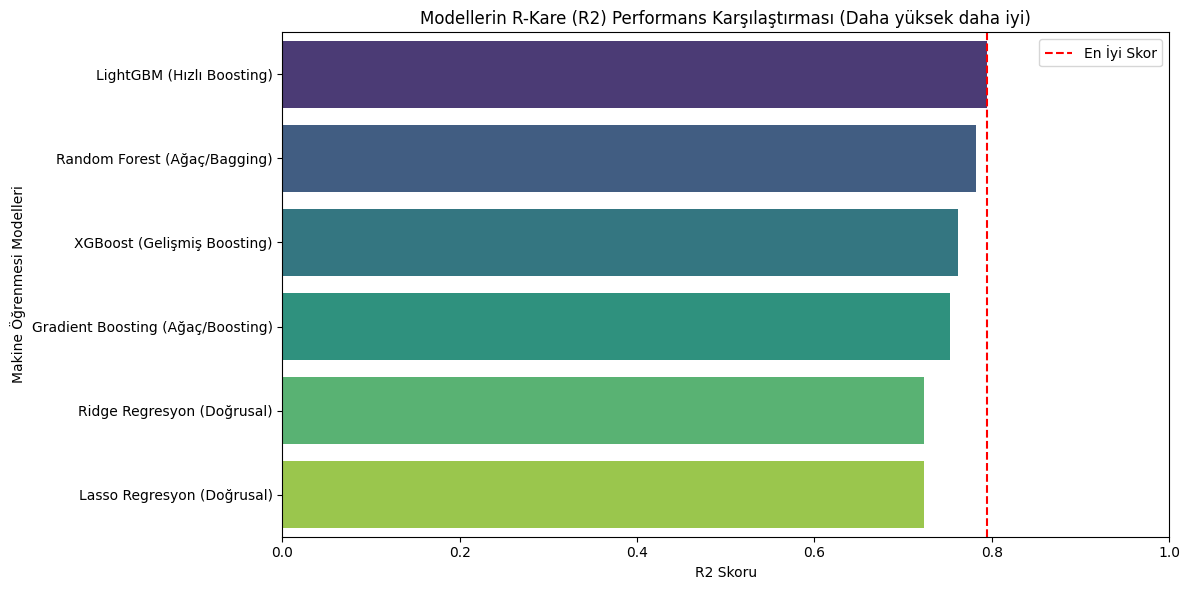

In [127]:
plt.figure(figsize=(12, 6))
sns.barplot(x='R2 Skoru', y='Model', data=results_df, palette='viridis')
plt.title('Modellerin R-Kare (R2) Performans Karşılaştırması (Daha yüksek daha iyi)')
plt.xlabel('R2 Skoru')
plt.ylabel('Makine Öğrenmesi Modelleri')
plt.xlim(0, 1) 
plt.axvline(x=results_df['R2 Skoru'].max(), color='red', linestyle='--', label='En İyi Skor')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_17332\971049386.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE', y='Model', data=results_df.sort_values(by='MAE', ascending=True), palette='magma')


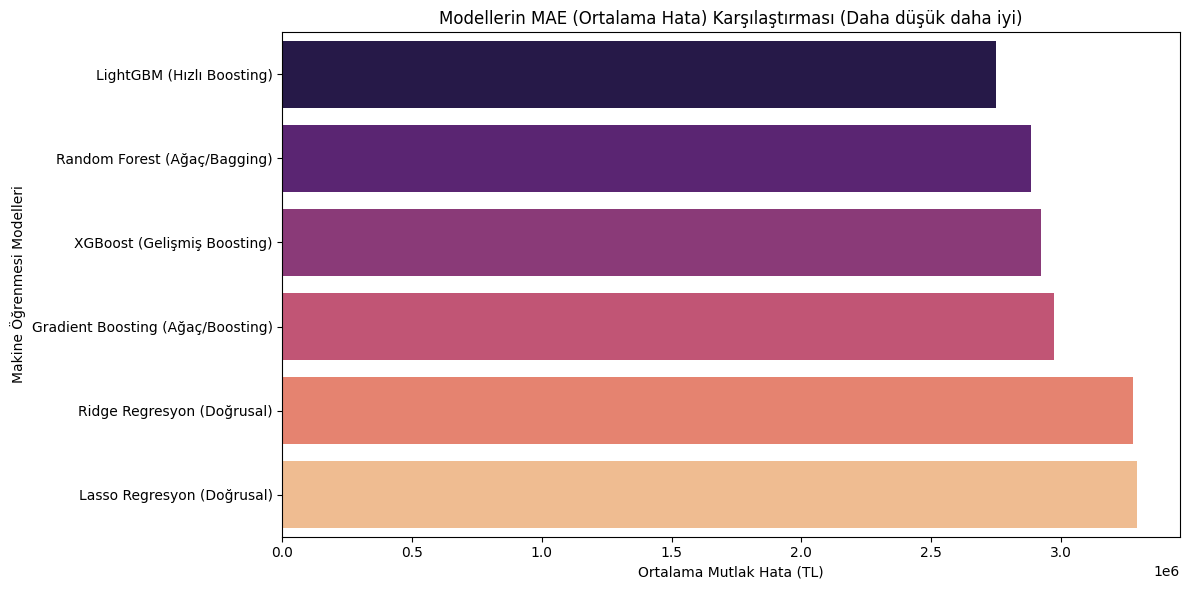

In [128]:
plt.figure(figsize=(12, 6))
sns.barplot(x='MAE', y='Model', data=results_df.sort_values(by='MAE', ascending=True), palette='magma')
plt.title('Modellerin MAE (Ortalama Hata) Karşılaştırması (Daha düşük daha iyi)')
plt.xlabel('Ortalama Mutlak Hata (TL)')
plt.ylabel('Makine Öğrenmesi Modelleri')
plt.tight_layout()
plt.show()

In [129]:
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))
])

param_grid = {
    'regressor__n_estimators': [100, 200, 300],        
    'regressor__learning_rate': [0.01, 0.05, 0.1],    
    'regressor__num_leaves': [31, 50, 100],            
    'regressor__max_depth': [-1, 10, 20]
}

In [146]:
from sklearn.model_selection import RandomizedSearchCV
grid_search = RandomizedSearchCV(
    estimator=lgbm_pipeline, 
    param_distributions=param_grid, 
    cv=3, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=1
)

In [147]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__learning_rate': [0.01, 0.05, ...], 'regressor__max_depth': [-1, 10, ...], 'regressor__n_estimators': [100, 200, ...], 'regressor__num_leaves': [31, 50, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation

In [148]:
best_model = grid_search.best_estimator_
grid_search.best_params_
preds = best_model.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"\n--- OPTİMİZE EDİLMİŞ LIGHTGBM SONUÇLARI ---")
print(f"R2 Skoru: {r2:.4f}")
print(f"MAE: {mae:,.0f} TL")
print(f"RMSE: {rmse:,.0f} TL")


--- OPTİMİZE EDİLMİŞ LIGHTGBM SONUÇLARI ---
R2 Skoru: 0.7811
MAE: 2,828,734 TL
RMSE: 4,355,085 TL


C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [149]:
grid_search.best_params_

{'regressor__num_leaves': 31,
 'regressor__n_estimators': 200,
 'regressor__max_depth': -1,
 'regressor__learning_rate': 0.05}